# Comparison of multilevel (Quasi-)Monte Carlo for an Asian option problem

Original QMCPy demo: [`QMCPy/demos/asian-option-mlqmc.ipynb`](../../QMCPy/demos/asian-option-mlqmc.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/asian_option_mlqmc.ipynb)

Compares MLMC, CubMLMCCont, MLQMC, and CubMLQMCCont for pricing an Asian call option under geometric Brownian motion.

Parity note: the QMCPy notebook runs the multilevel comparison at `abs_tol=5e-3`. On the current Julia implementation that target drives the checked-in demo into roughly `10^8` sample counts locally, so this notebook keeps a looser tolerance sweep while preserving the same MLMC versus MLQMC comparison structure.


In [1]:
using QMC
import QMC: Uniform
using Statistics

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


Compute the exact value of the Asian option with single-level QMC, for an increasing number of time steps:

In [2]:
let
    for level in 0:4
        d_steps = 2 * 2^level
        dd_level = DigitalNetB2(d_steps; seed=7, randomize="LMS_DS", graycode=false)
        tm_level = GeometricBrownianMotion(dd_level;
            volatility=0.2, start_price=100.0,
            interest_rate=0.05, t_final=1.0)
        fo_level = FinancialOption(tm_level; option_type=:asian, strike_price=100.0)
        sc_level = CubQMCNetG(fo_level; abs_tol=1e-4)
        result_level = integrate(sc_level)
        println("$(lpad(d_steps, 3)) time steps: $(round(result_level.solution, digits=5))")
    end
end

  2 time steps: 8.11118


  4 time steps: 6.9395


  8 time steps: 6.35223


 16 time steps: 6.05795


 32 time steps: 5.9106


This function compares 4 different algorithms: Multilevel Monte Carlo (`CubMLMC`), continuation Multilevel Monte Carlo (`CubMLMCCont`), Multilevel Quasi-Monte Carlo (`CubMLQMC`) and continuation Multilevel Quasi-Monte Carlo (`CubMLQMCCont`):

In [3]:
# Setup MC and QMC versions
function compare_ml(abs_tol)
    dd_mc  = IIDStdUniform(16; seed=7)
    dd_qmc = DigitalNetB2(16; seed=7, replications=8)
    tm_mc  = GeometricBrownianMotion(dd_mc;  volatility=0.2, start_price=100.0,
                interest_rate=0.05, t_final=1.0)
    tm_qmc = GeometricBrownianMotion(dd_qmc; volatility=0.2, start_price=100.0,
                interest_rate=0.05, t_final=1.0)
    fml_mc  = FinancialOptionML(tm_mc;  d_coarsest=4, strike_price=100.0)
    fml_qmc = FinancialOptionML(tm_qmc; d_coarsest=4, strike_price=100.0)

    results = Dict{String, Any}()
    for (name, sc) in [
        ("MLMC",      CubMLMC(fml_mc;      abs_tol=abs_tol)),
        ("MLMCCont",  CubMLMCCont(fml_mc;  abs_tol=abs_tol)),
        ("MLQMC",     CubMLQMC(fml_qmc;    abs_tol=abs_tol)),
        ("MLQMCCont", CubMLQMCCont(fml_qmc; abs_tol=abs_tol)),
    ]
        r = integrate(sc)
        n_used = get(r.data, :n_total, get(r.data, :n, 0))
        results[name] = (solution=r.solution, n=n_used)
        println("  $name: sol=$(round(r.solution, digits=5)), n=$n_used")
    end
    return results
end

for tol in [1e-1, 5e-2]
    println("\nabs_tol = $tol")
    compare_ml(tol)
end


abs_tol = 0.1


  MLMC: sol=5.79849, n=228299


  MLMCCont: sol=5.77842, n=217199


  MLQMC: sol=5.85363, n=47104


  MLQMCCont: sol=5.90918, n=22528



abs_tol = 0.05
  MLMC: sol=5.78079, n=934734


  MLMCCont: sol=5.82134, n=895244


  MLQMC: sol=5.79676, n=301056


  MLQMCCont: sol=5.79003, n=59392


## Sampler Comparison Visualization


Running comparison for plot (tol=1e-1)...
  MLMC: sol=5.783, n=229337
  MLMCCont: sol=5.87079, n=205419
  MLQMC: sol=5.83006, n=43008
  MLQMCCont: sol=5.8211, n=43008


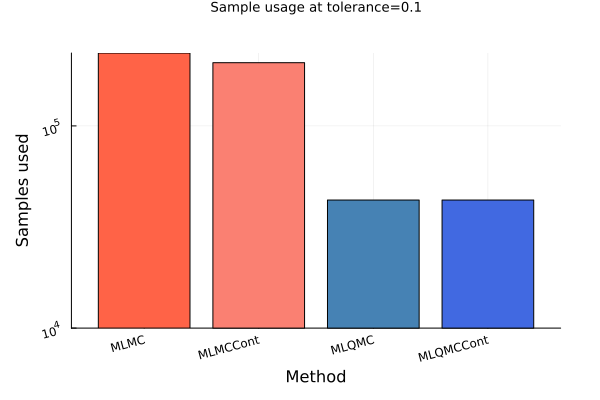

In [4]:
if HAVE_PLOTS
    # Run one tolerance comparison and visualise
    println("Running comparison for plot (tol=1e-1)...")
    tol_plot = 1e-1
    res_plot = compare_ml(tol_plot)

    methods_plot = ["MLMC", "MLMCCont", "MLQMC", "MLQMCCont"]
    n_used_plot  = [res_plot[m].n for m in methods_plot]
    colors_bar   = [:tomato, :salmon, :steelblue, :royalblue]

    p = bar(methods_plot, n_used_plot;
        color=colors_bar,
        xlabel="Method", ylabel="Samples used",
        title="Sample usage at tolerance=$(tol_plot)",
        legend=false, rotation=15, yscale=:log10)
    display(p)
end
